# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [13]:
# You may include any package you deem fit. We sugggest looking into Scikit-learn
import pandas as pd
import seaborn as sns

## Dataset


In [25]:
# DO NOT MODIFY
loan_data = pd.read_csv("../../data/loan_approval.csv")
loan_data

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


## EDA
Uncomment to see desired output. Add more analysis if you like

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')
           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    

loan_id                        Axes(0.125,0.712609;0.168478x0.167391)
no_of_dependents            Axes(0.327174,0.712609;0.168478x0.167391)
income_annum                Axes(0.529348,0.712609;0.168478x0.167391)
loan_amount                 Axes(0.731522,0.712609;0.168478x0.167391)
loan_term                      Axes(0.125,0.511739;0.168478x0.167391)
cibil_score                 Axes(0.327174,0.511739;0.168478x0.167391)
residential_assets_value    Axes(0.529348,0.511739;0.168478x0.167391)
commercial_assets_value     Axes(0.731522,0.511739;0.168478x0.167391)
luxury_assets_value             Axes(0.125,0.31087;0.168478x0.167391)
bank_asset_value             Axes(0.327174,0.31087;0.168478x0.167391)
dtype: object

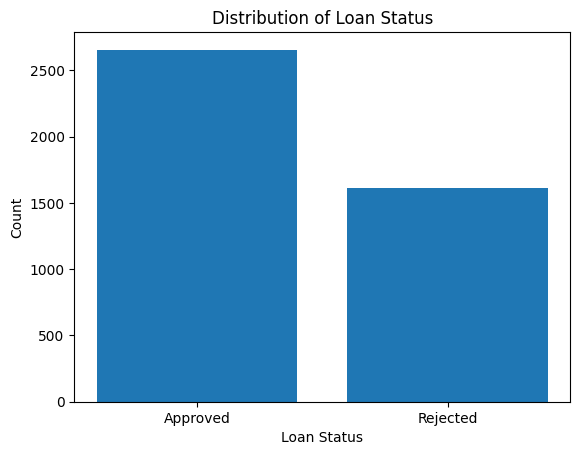

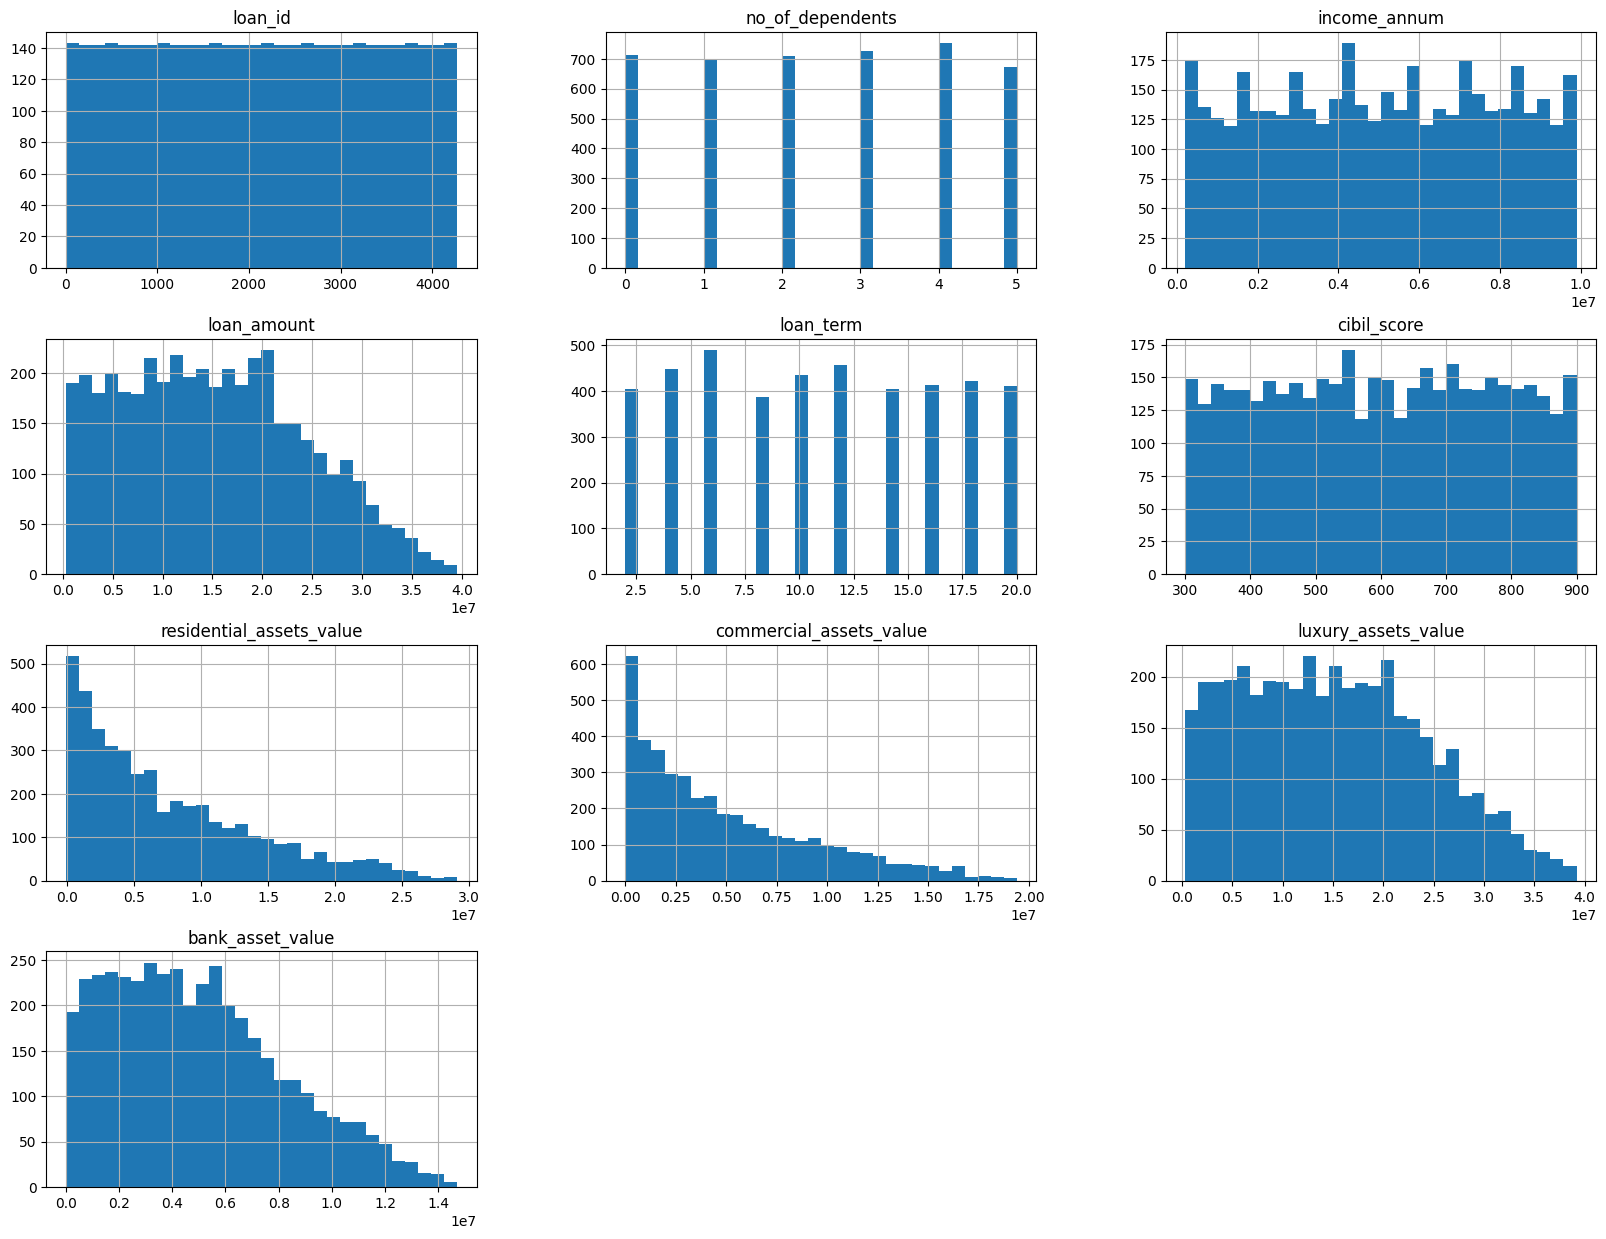

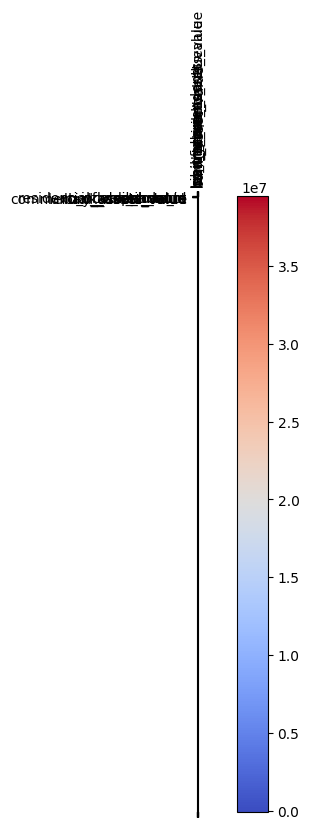

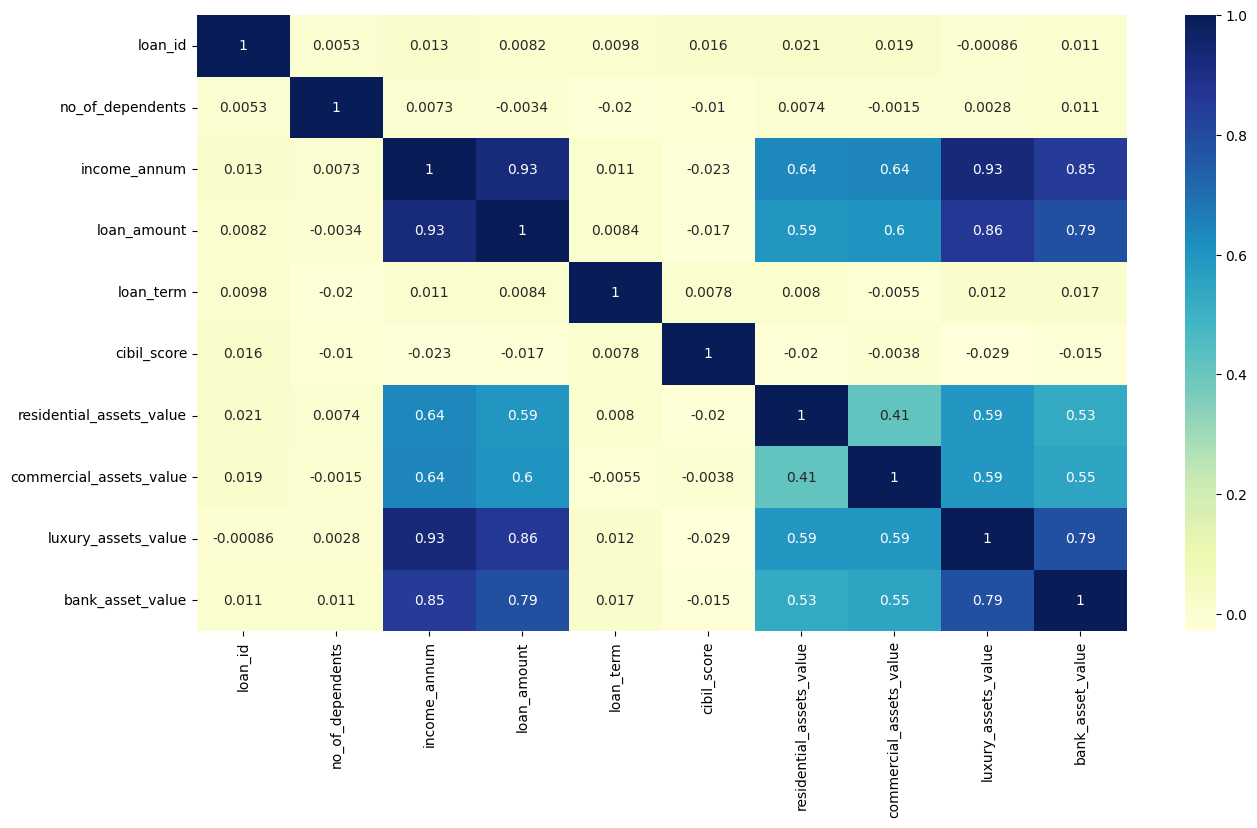

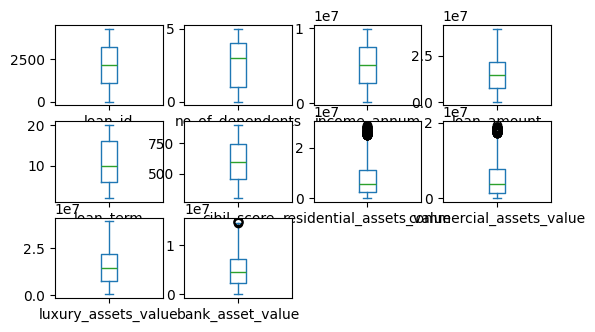

In [15]:

import matplotlib.pyplot as plt

# ------ Display basic information ------
print(loan_data.columns)
print(loan_data.describe())

# ------ Check for missing values ------
print(loan_data.isnull().sum())

# ------ Visualize the distribution of loan status ------
loan_status_counts = loan_data['loan_status'].value_counts()
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# ------ Visualize the distribution of numerical features ------ 
loan_data.hist(bins=30, figsize=(20, 15))

# ------ Correlation matrix ------
#Does not seem to be working properly, instead see correlation map below with yellow green blue colors
corr_matrix = loan_data.select_dtypes(include="number")
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# ----- MORE (Encouraged but not required) ------
loan_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(loan_data.corr(numeric_only=True), annot = True, cmap = "YlGnBu")
#Helps to see the quartiles and medians of eacn value
loan_data.plot(kind ='box',subplots = True, layout =(4,4),sharex = False)

The graphs above reveal many interesting things about the data set. Namely, looking at the correlation graph shows us that the loan amount and the income amount have a high positive correlation, which makes sense. However, it shows us that the majority of values do not have a correlation with each of the other values. The box plots of each of the values tell us what the medians and quartiles look like.

## Feature Engineering

You may want to convert categorical variables to numerical. For example, education takes on the value Graduate and Not Graduate. But we want it to be 0 or 1 for machine learning algorithms to use.

In [30]:
#loan_data['education'] = loan_data['education'].map({'Graduate': 1, 'Not Graduate': 0})
# Hint: Other categorical variables are self_employed and loan_status
#loan_data['self_employed'] = loan_data['self_employed'].map({'Yes': 1, 'No': 0})
#loan_data['loan_status'] = loan_data['loan_status'].map({'Approved': 1, 'Rejected': 0})

#Adding additional features that I think would correlate well with loan_status
loan_data["amt_per_inc"] = loan_data["loan_amount"]/loan_data["income_annum"]
loan_data["total_assets_per_inc"] = (loan_data["residential_assets_value"]+ loan_data["commercial_assets_value"]+ loan_data["luxury_assets_value"]+ loan_data["bank_asset_value"])/loan_data["income_annum"]
loan_data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,amt_per_inc,total_assets_per_inc
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.114583,5.281250
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.975610,4.146341
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.263736,6.340659
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.743902,6.426829
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.469388,5.612245


<Axes: >

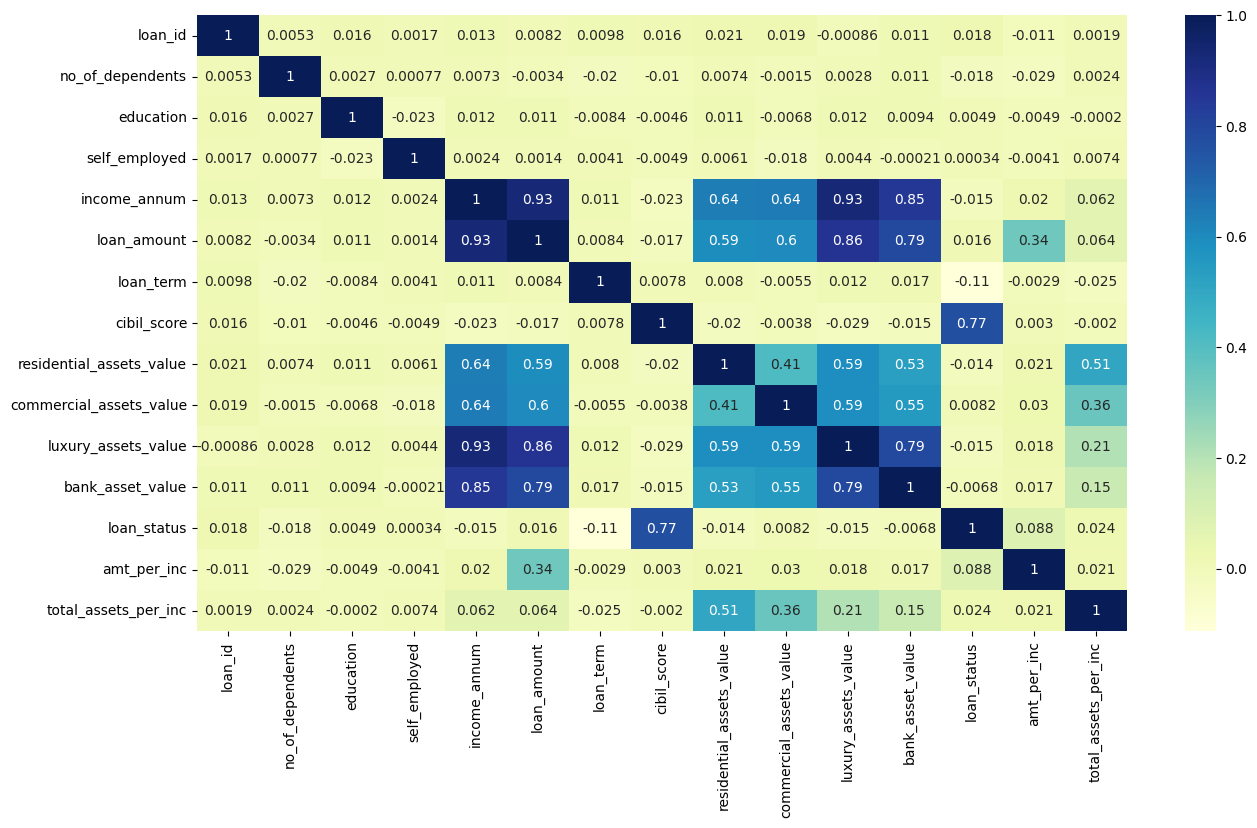

In [31]:
#Reshowing correlation since now we have made all values numerical
loan_data.corr(numeric_only=True)
plt.figure(figsize=(15,8))
sns.heatmap(loan_data.corr(numeric_only=True), annot = True, cmap = "YlGnBu")

The features I added did not correlate too much with loan status, however amount per income does have the second highest correlation among all features

## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

In [42]:
# TODO
from sklearn.model_selection import train_test_split

X = loan_data.drop(['loan_status'], axis = 1)
y = loan_data["loan_status"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
train_data = X_train.join(y_train)

In [44]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
forest.score(X_test, y_test)

0.9901010564663024

Score is really good, but lets see if we can optimize it further by using grid_search

## Model Optimization and Testing

In [46]:
from sklearn.model_selection import GridSearchCV
forest  = RandomForestRegressor() #Defining a new one so we don't have to use the one we already used above
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 4],
    "min_samples_split": [2, 4]
}
grid_search = GridSearchCV(forest, param_grid, cv=5,
                           scoring = "neg_mean_squared_error",
                           return_train_score=True)
grid_search.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 4], 'min_samples_split': [2, 4], 'n_estimators': [100, 300]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [47]:
best_forest = grid_search.best_estimator_

In [48]:
best_forest.score(X_test, y_test)

0.9891802709245135

Our score actually got a bit worse! It is possible to overdo hyperparameter tuning and random fluctuations may make fitting and scores worse than we think. let us try KNN

In [58]:
print(len(X_train))

3415


In [59]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
model_2 = KNeighborsClassifier(n_neighbors=3415) # n_neighbors refers to the number of nearest data points that the algorithm considers when making a prediction for a new, unclassified data point.
model_2.fit(X_train, y_train)
y_pred = model_2.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test, y_pred))

Accuracy Score: 0.6428571428571429


In [ ]:
The max accuracy score for KNN seems to be around 65%, though more testing is necessary. Currently, the best predictor by far is the random_forst, whcih 